In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # how many cpu to use
os.environ["MKL_NUM_THREADS"] = "1" #Used by Intel MKL (math library)

In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("large_credit_risk_dataset.csv")

In [4]:
df

,income,loan_amount,employment_years,age,credit_score,existing_loans,dependents,loan_term_months,interest_rate,late_payments,credit_utilization,savings_balance,checking_balance,has_credit_card,has_mortgage,default
0,141958,655635,19,36,441,7,0,24,11.56,1,0.34,405494,157909,1,1,1
1,166867,112668,10,58,645,7,3,48,10.44,7,0.65,353631,45950,1,0,0
2,151932,799446,18,65,852,4,1,36,14.74,2,0.86,266291,107662,1,0,1
3,279178,318623,26,60,860,1,4,24,23.23,6,0.70,355937,46846,0,0,0
4,139879,296340,23,34,532,7,1,60,24.66,0,0.41,379188,121814,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,284458,368237,2,36,470,6,2,48,16.97,3,0.38,14886,84691,0,1,0
49996,147931,299018,36,69,709,0,3,60,17.52,2,0.18,314242,55038,0,0,0
49997,152629,910252,2,30,550,5,0,12,20.66,1,0.75,192896,41316,0,0,1
49998,117385,328425,21,68,493,1,1,48,22.40,0,0.95,120734,145437,1,0,1


###   Target Distribution (IMBALANCE CHECK)

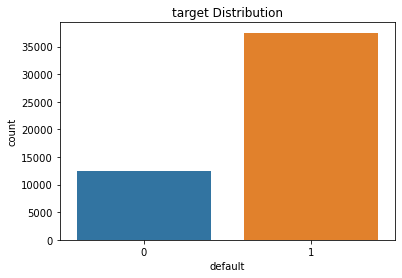

In [5]:
sns.countplot(x="default",data=df)
plt.title("target Distribution")
plt.show()

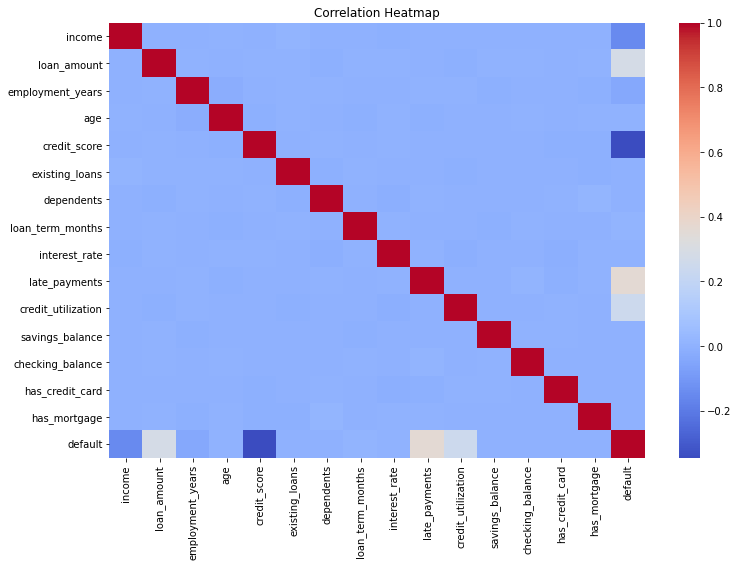

In [6]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

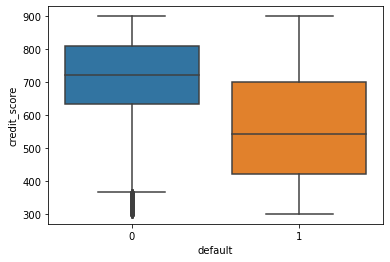

In [7]:
sns.boxplot(x="default",y="credit_score",data=df)
plt.show()

In [8]:
df['dept_to_income']=df['loan_amount']/df['income']  # in what ratio u in depth

In [9]:
df['emi_estimate']=df['loan_amount']/df['loan_term_months'] # how much emi pending

In [10]:
df

,income,loan_amount,employment_years,age,credit_score,existing_loans,dependents,loan_term_months,interest_rate,late_payments,credit_utilization,savings_balance,checking_balance,has_credit_card,has_mortgage,default,dept_to_income,emi_estimate
0,141958,655635,19,36,441,7,0,24,11.56,1,0.34,405494,157909,1,1,1,4.618514,27318.125000
1,166867,112668,10,58,645,7,3,48,10.44,7,0.65,353631,45950,1,0,0,0.675196,2347.250000
2,151932,799446,18,65,852,4,1,36,14.74,2,0.86,266291,107662,1,0,1,5.261867,22206.833333
3,279178,318623,26,60,860,1,4,24,23.23,6,0.70,355937,46846,0,0,0,1.141290,13275.958333
4,139879,296340,23,34,532,7,1,60,24.66,0,0.41,379188,121814,0,0,1,2.118545,4939.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,284458,368237,2,36,470,6,2,48,16.97,3,0.38,14886,84691,0,1,0,1.294522,7671.604167
49996,147931,299018,36,69,709,0,3,60,17.52,2,0.18,314242,55038,0,0,0,2.021334,4983.633333
49997,152629,910252,2,30,550,5,0,12,20.66,1,0.75,192896,41316,0,0,1,5.963821,75854.333333
49998,117385,328425,21,68,493,1,1,48,22.40,0,0.95,120734,145437,1,0,1,2.797845,6842.187500


In [11]:
print(df.isnull().sum())

income                0
loan_amount           0
employment_years      0
age                   0
credit_score          0
existing_loans        0
dependents            0
loan_term_months      0
interest_rate         0
late_payments         0
credit_utilization    0
savings_balance       0
checking_balance      0
has_credit_card       0
has_mortgage          0
default               0
dept_to_income        0
emi_estimate          0
dtype: int64


In [12]:
from sklearn.model_selection import train_test_split
X=df.drop("default",axis=1)
y=df['default']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
df.head()

,income,loan_amount,employment_years,age,credit_score,existing_loans,dependents,loan_term_months,interest_rate,late_payments,credit_utilization,savings_balance,checking_balance,has_credit_card,has_mortgage,default,dept_to_income,emi_estimate
0,141958,655635,19,36,441,7,0,24,11.56,1,0.34,405494,157909,1,1,1,4.618514,27318.125000
1,166867,112668,10,58,645,7,3,48,10.44,7,0.65,353631,45950,1,0,0,0.675196,2347.250000
2,151932,799446,18,65,852,4,1,36,14.74,2,0.86,266291,107662,1,0,1,5.261867,22206.833333
3,279178,318623,26,60,860,1,4,24,23.23,6,0.70,355937,46846,0,0,0,1.141290,13275.958333
4,139879,296340,23,34,532,7,1,60,24.66,0,0.41,379188,121814,0,0,1,2.118545,4939.000000


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numcols= X.columns
preprocessor=ColumnTransformer([("num",StandardScaler(),numcols)])

In [15]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.pipeline import Pipeline  
from sklearn.metrics import classification_report,roc_auc_score,roc_curve,accuracy_score
from imblearn.over_sampling import SMOTE
    
import shap

In [16]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}


===== Logistic Regression =====
Accuracy: 0.8465
AUC: 0.9316327496140677
              precision    recall  f1-score   support

           0       0.65      0.85      0.74      2538
           1       0.94      0.85      0.89      7462

    accuracy                           0.85     10000
   macro avg       0.80      0.85      0.81     10000
weighted avg       0.87      0.85      0.85     10000



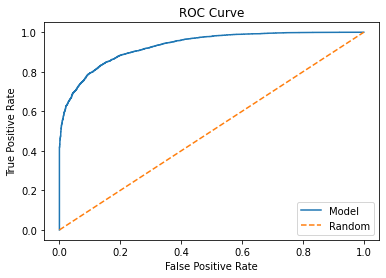

AUC: 0.9316327496140677

===== Random Forest =====
Accuracy: 1.0
AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2538
           1       1.00      1.00      1.00      7462

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



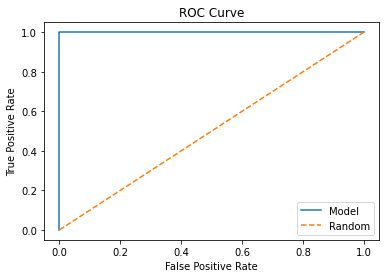

AUC: 1.0
 SHAP for Random Forest


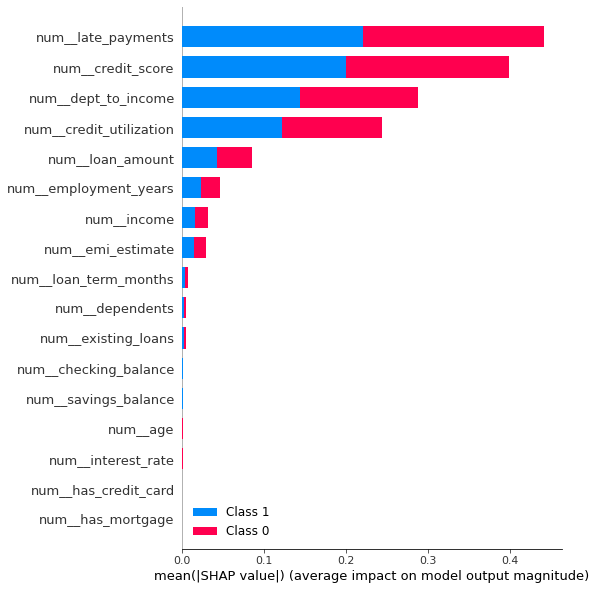


===== XGBoost =====
Accuracy: 0.9984
AUC: 0.9999582861544459
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2538
           1       1.00      1.00      1.00      7462

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



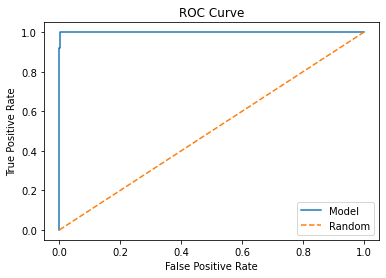

AUC: 0.9999582861544459
 SHAP for XGBoost


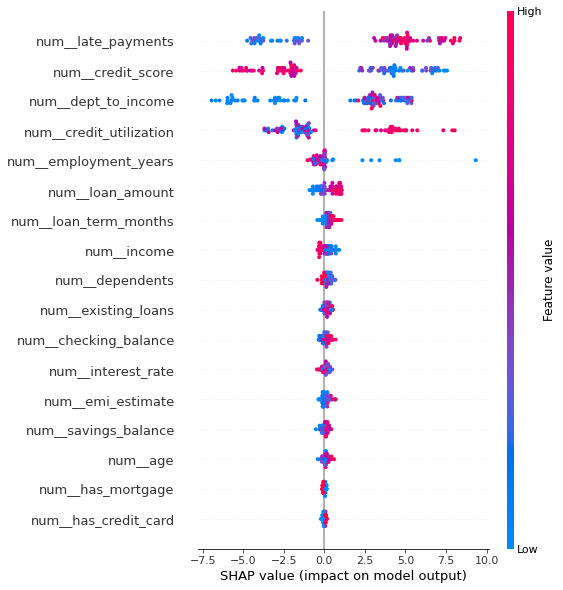

In [17]:

for name,model in models.items():
    pipeline=Pipeline(steps=[("Preprocessor",preprocessor),("smote",SMOTE(random_state=42)),("model",model)])
    pipeline.fit(X_train,y_train)
    y_pred=pipeline.predict(X_test)
    y_prob=pipeline.predict_proba(X_test)[:,1]
    
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("AUC:", roc_auc_score(y_test, y_prob))
    print(classification_report(y_test, y_pred))
    
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label="Model")
    plt.plot([0,1],[0,1], linestyle="--", label="Random")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()

    plt.show()

    print("AUC:", roc_auc_score(y_test, y_prob))
    
    
    
    if name in ['Random Forest','XGBoost']:
        print(f" SHAP for {name}")
        
        trained_model=pipeline.named_steps["model"]
        X_test_transformed=pipeline.named_steps['Preprocessor'].transform(X_test)
        feature_name=pipeline.named_steps['Preprocessor'].get_feature_names_out()
        X_test_df=pd.DataFrame(X_test_transformed,columns=feature_name)
        explainer=shap.TreeExplainer(trained_model)
        shap_value=explainer.shap_values(X_test_df[:100])
        shap.summary_plot(shap_value,X_test_df[:100])


### Checking for model consistency 

In [18]:
from sklearn.model_selection import StratifiedKFold,GridSearchCV,cross_val_score

cross=cross_val_score(pipeline,X,y,scoring="roc_auc")

print("CV Scores:", cross)
print("Mean CV Score:", cross.mean())

CV Scores: [0.99999242 0.99999204 0.99993348 1.         0.99999621]
Mean CV Score: 0.9999828298729463


In [19]:
train_score = pipeline.score(X_train, y_train)
test_score = pipeline.score(X_test, y_test)

print(train_score, test_score)

1.0 0.9984


In [20]:
import numpy as np
from sklearn.model_selection import cross_val_score

y_shuffled = np.random.permutation(y)

scores = cross_val_score(pipeline, X, y_shuffled, cv=5)
print(scores.mean())

0.74186


## HYPERPARAMTER TUNE

In [23]:
param_grid={"model__n_estimator":[100,200],
           "model__max_depth":[3,5],
           "model__learning_rate":[0.01,0.1]}


grid=GridSearchCV(model,param_grid,cv=3,scoring="roc_auc",verbose=1)
grid.fit(X_train,y_train)
print("Best params:",grid.best_params_)
print("Best Score:",grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimator': 100}
Best Score: 0.9999973903524867


### Saving PKL files


In [21]:
import joblib
joblib.dump(model, "credit_model.pkl")

['credit_model.pkl']